<a href="https://colab.research.google.com/github/Timur228228228/-/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Анализ датасета Wine Quality (red wine)

### Цель проекта
Провести разведочный анализ данных (EDA) для датасета **Wine Quality** и построить модели, предсказывающие качество вина по его физико-химическим характеристикам.

### Постановка задачи
В проекте рассматривается задача **бинарной классификации**:

- `1` — вино хорошего качества, если `quality >= 6`
- `0` — иначе

### Задачи проекта

Загрузить датасет. Далее изучаем его структуру данных,проверяем пропуски и дубликаты, исследовть распределение признаков, оценить коллеряции между признаками. Далее обучим и сравним несколько моделей классификации, оценим качество моделей и выберем лучшую

### Метрики качества
Для оценки моделей будут использоваться: Accuracy, Precision, Recall, F1-score, ROC-AUC




In [1]:

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


In [34]:
DATA_PATH = "winequality-red.csv"
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, sep=";")
else:
    df = pd.read_csv(DATA_URL, sep=";")

print(df.head().to_string())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  alcohol  quality
0            7.4              0.70         0.00             1.9      0.076                 11.0                  34.0   0.9978  3.51       0.56      9.4        5
1            7.8              0.88         0.00             2.6      0.098                 25.0                  67.0   0.9968  3.20       0.68      9.8        5
2            7.8              0.76         0.04             2.3      0.092                 15.0                  54.0   0.9970  3.26       0.65      9.8        5
3           11.2              0.28         0.56             1.9      0.075                 17.0                  60.0   0.9980  3.16       0.58      9.8        6
4            7.4              0.70         0.00             1.9      0.076                 11.0                  34.0   0.9978  3.51       0.56      9.4        5


Датасет успешно загружен.
По первым строкам видно, что каждый объект представляет собой отдельное вино, а столбцы содержат его характеристики.
В таблице присутствует признак quality, который можно использовать как целевую переменную в дальнейшей задаче классификации.

In [5]:

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nТипы данных:")
display(df.dtypes)

print("\nИнформация о датасете:")
df.info()


Размер датасета: 1599 строк, 12 столбцов

Типы данных:


,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


По результатам просмотра структуры датасета видно, что в нём содержится 1599 строк и 12 столбцов.

In [44]:
desc = df.describe().T.round(3)
print(desc.to_string())

                       count    mean     std    min     25%     50%     75%      max
fixed acidity         1599.0   8.320   1.741  4.600   7.100   7.900   9.200   15.900
volatile acidity      1599.0   0.528   0.179  0.120   0.390   0.520   0.640    1.580
citric acid           1599.0   0.271   0.195  0.000   0.090   0.260   0.420    1.000
residual sugar        1599.0   2.539   1.410  0.900   1.900   2.200   2.600   15.500
chlorides             1599.0   0.087   0.047  0.012   0.070   0.079   0.090    0.611
free sulfur dioxide   1599.0  15.875  10.460  1.000   7.000  14.000  21.000   72.000
total sulfur dioxide  1599.0  46.468  32.895  6.000  22.000  38.000  62.000  289.000
density               1599.0   0.997   0.002  0.990   0.996   0.997   0.998    1.004
pH                    1599.0   3.311   0.154  2.740   3.210   3.310   3.400    4.010
sulphates             1599.0   0.658   0.170  0.330   0.550   0.620   0.730    2.000
alcohol               1599.0  10.423   1.066  8.400   9.500  10.2

In [7]:

missing = df.isna().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()

print("Количество пропусков по столбцам:")
display(missing)

print(f"Количество полных дубликатов: {duplicates}")


Количество пропусков по столбцам:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Количество полных дубликатов: 240


Проверка показала, что в датасете отсутствуют пропущенные значения, что упрощает дальнейшую работу с данными.
При этом было обнаружено 240 полных дубликатов.
Это означает, что в данных есть повторяющиеся строки, поэтому на этапе предобработки такие наблюдения желательно удалить, чтобы они не влияли на результаты анализа и обучения моделей.

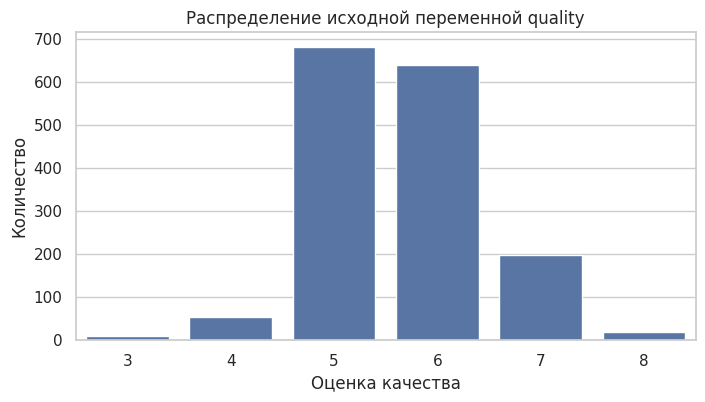

In [8]:

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="quality")
plt.title("Распределение исходной переменной quality")
plt.xlabel("Оценка качества")
plt.ylabel("Количество")
plt.show()


По графику распределения переменной quality видно, что чаще всего в датасете встречаются вина с оценками 5 и 6.
Оценки 3, 4 и 8 представлены значительно реже.
Это показывает, что распределение целевой переменной не является равномерным: основная часть наблюдений сосредоточена около средних значений качества.

In [12]:
df["target"] = (df["quality"] >= 6).astype(int)

class_counts = df["target"].value_counts().sort_index()
class_share = df["target"].value_counts(normalize=True).sort_index()

print("Баланс классов после бинаризации:")
print(class_counts)

print("\nДоли классов:")
print(class_share)


Баланс классов после бинаризации:
target
0    744
1    855
Name: count, dtype: int64

Доли классов:
target
0    0.465291
1    0.534709
Name: proportion, dtype: float64


Это означает, что сильного дисбаланса классов в данных нет, поэтому модели будут обучаться в более сбалансированных условиях. Это так, потому что после бинаризации целевой переменной классы распределены достаточно равномерно:
класс 0 составляет около 46.5%, а класс 1 — около 53.5%.

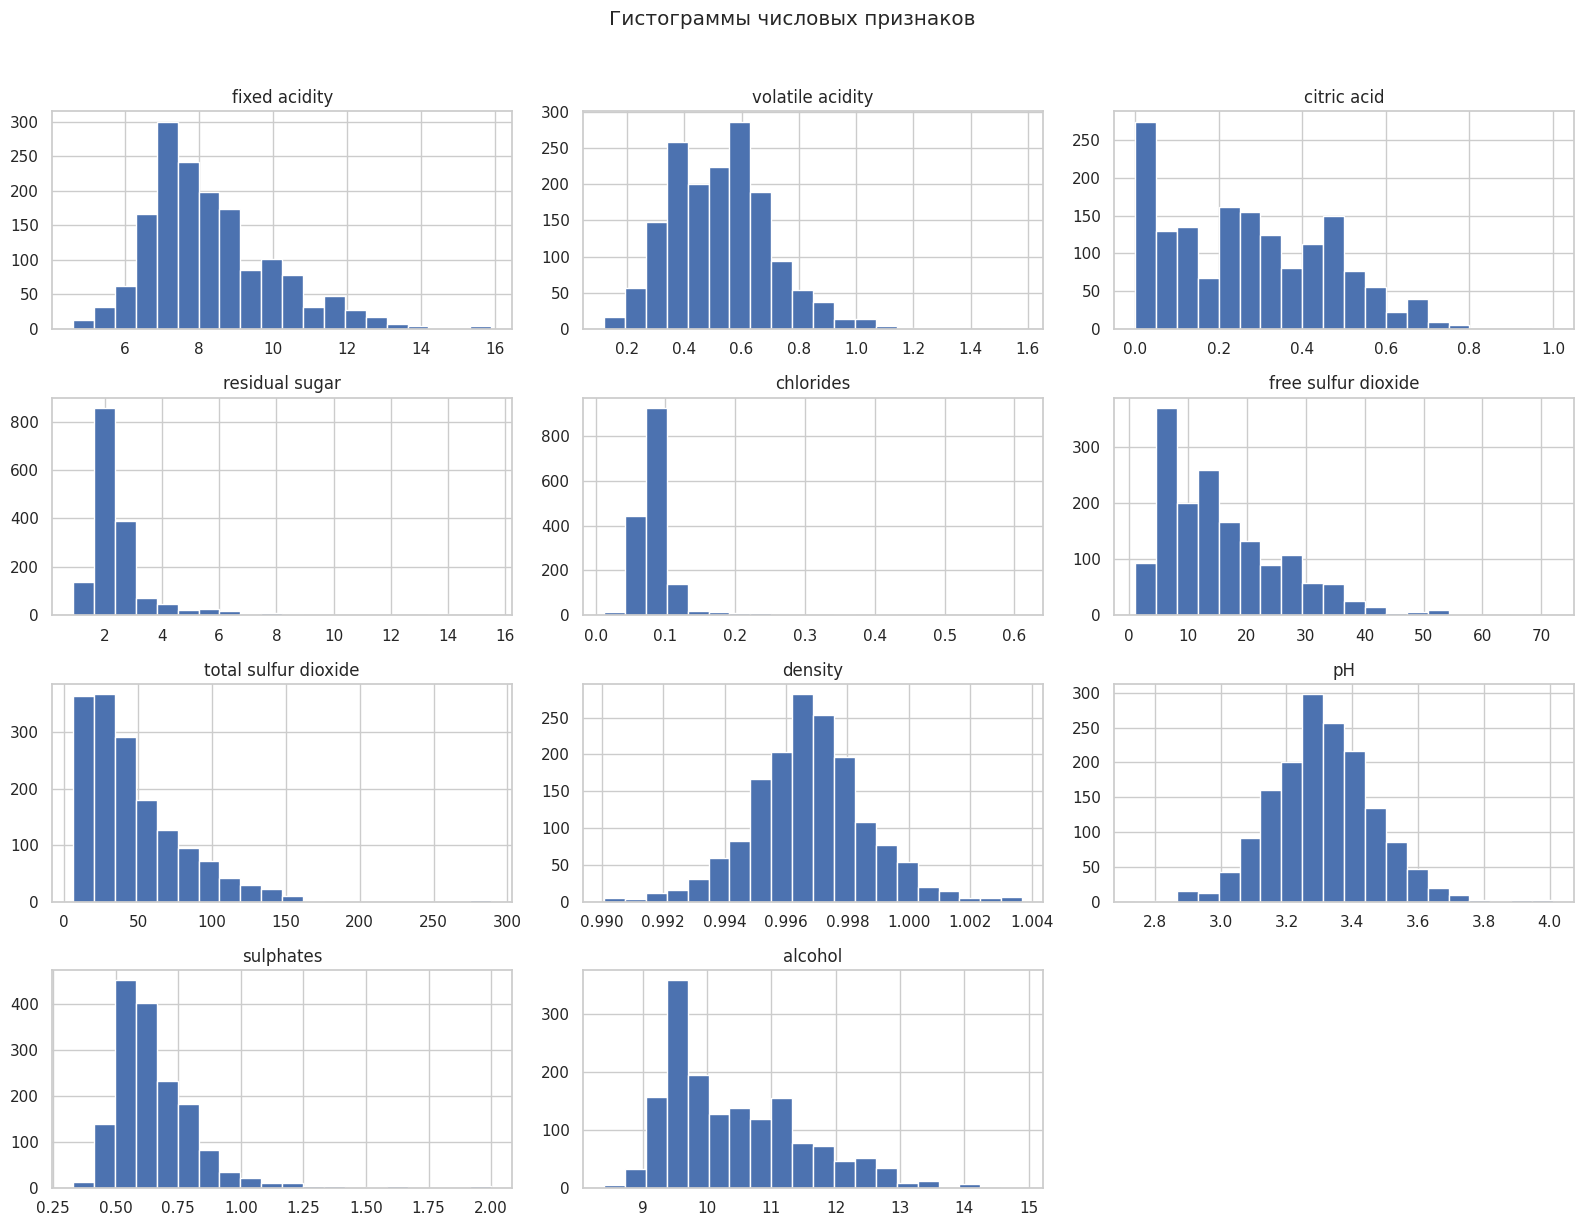

In [13]:

features = [col for col in df.columns if col not in ["quality", "target"]]

df[features].hist(figsize=(16, 12), bins=20)
plt.suptitle("Гистограммы числовых признаков", y=1.02)
plt.tight_layout()
plt.show()


По гистограммам видно, что признаки распределены по-разному.
У некоторых признаков значения сосредоточены в узком диапазоне, а у других есть длинные хвосты и редкие большие значения.
Это показывает, что данные требуют внимательного анализа перед обучением моделей.

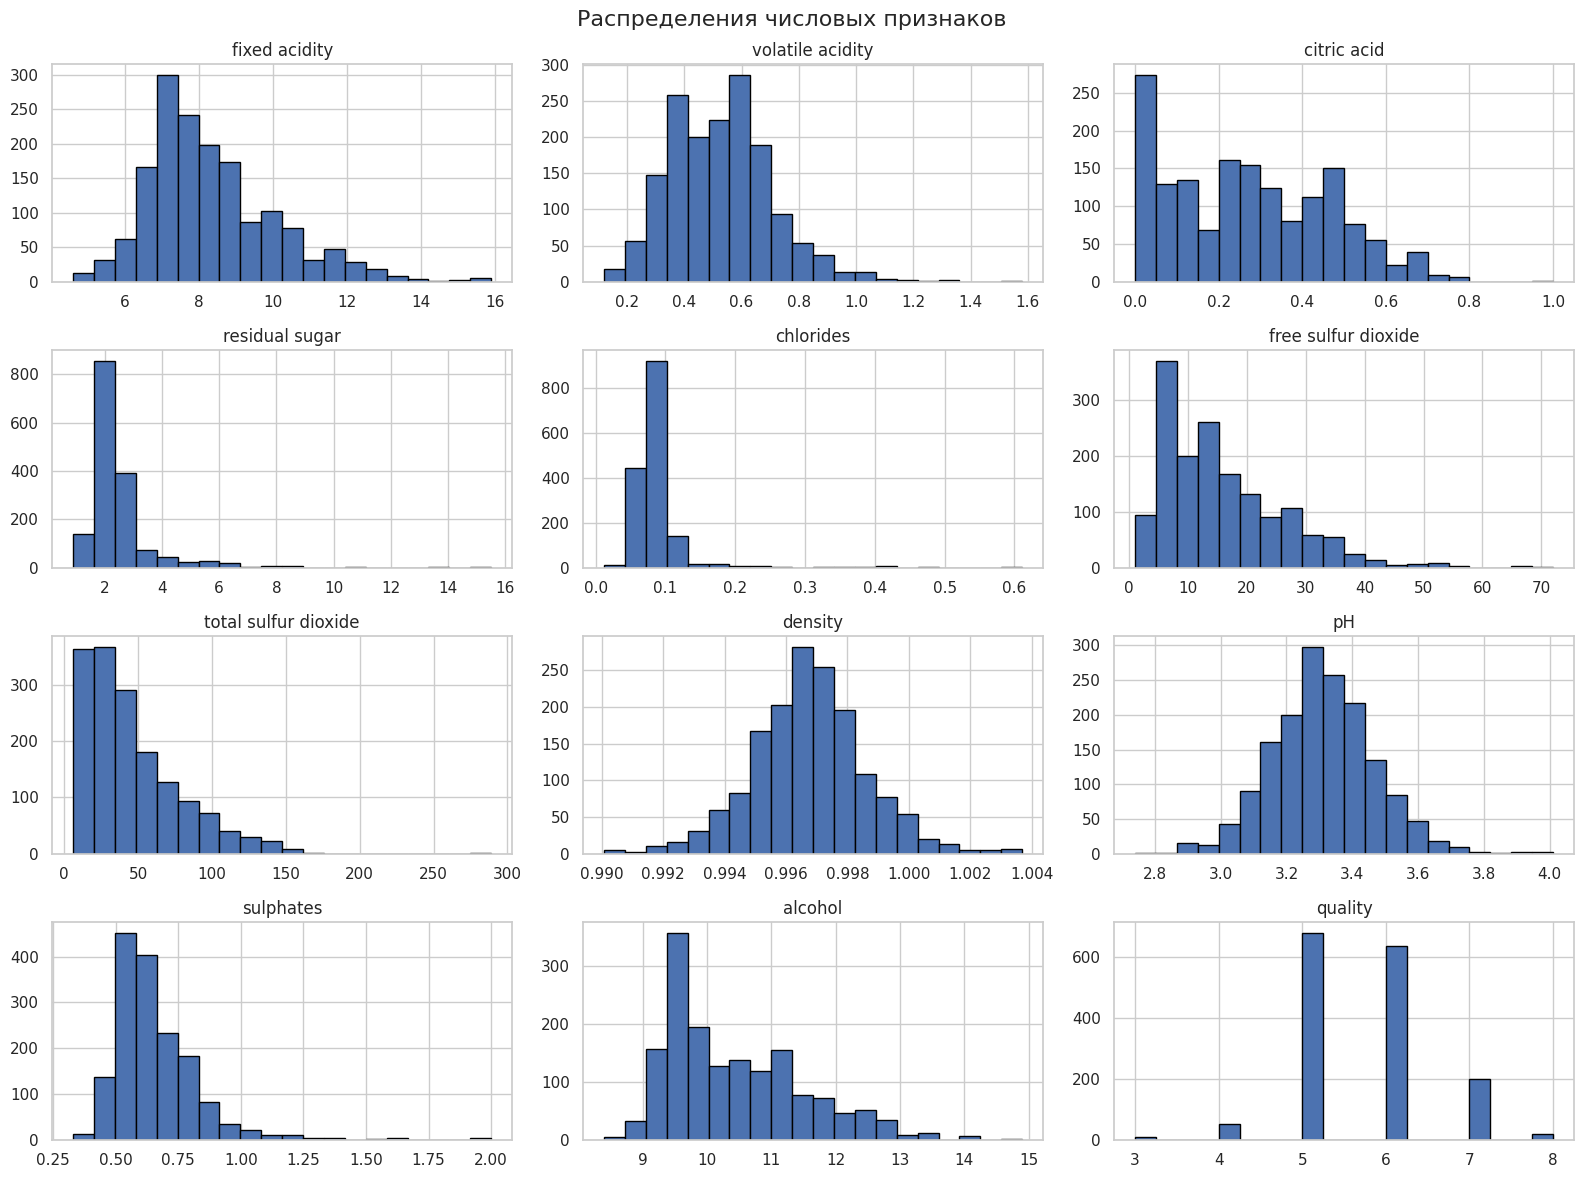

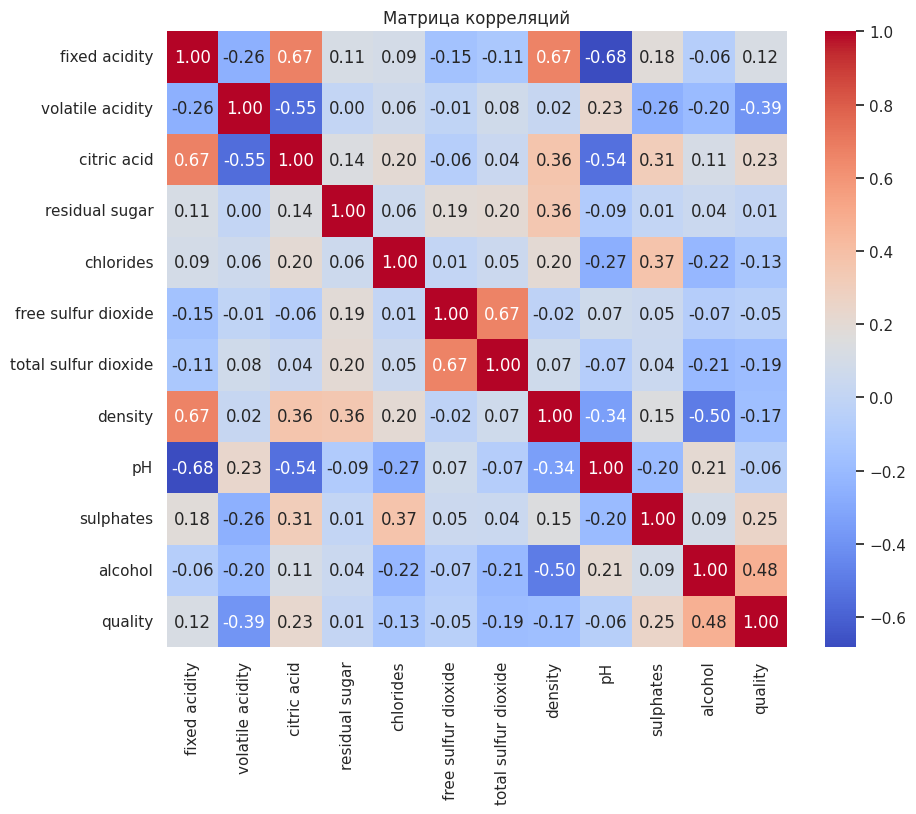

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns

# 1. Гистограммы распределений признаков
df[numeric_cols].hist(figsize=(16, 12), bins=20, edgecolor="black")
plt.suptitle("Распределения числовых признаков", fontsize=16)
plt.tight_layout()
plt.show()

# 2. Матрица корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Матрица корреляций")
plt.show()

По гистограммам видно, что признаки распределены неодинаково: где-то значения сосредоточены в узком диапазоне, а где-то есть длинные хвосты.
Матрица корреляций помогает понять, какие признаки сильнее связаны между собой.

значение, близкое к 1, означает сильную прямую связь: при увеличении одного признака другой тоже обычно увеличивается;
значение, близкое к -1, означает сильную обратную связь: при увеличении одного признака другой уменьшается;
значение, близкое к 0, говорит о слабой или отсутствующей линейной связи.

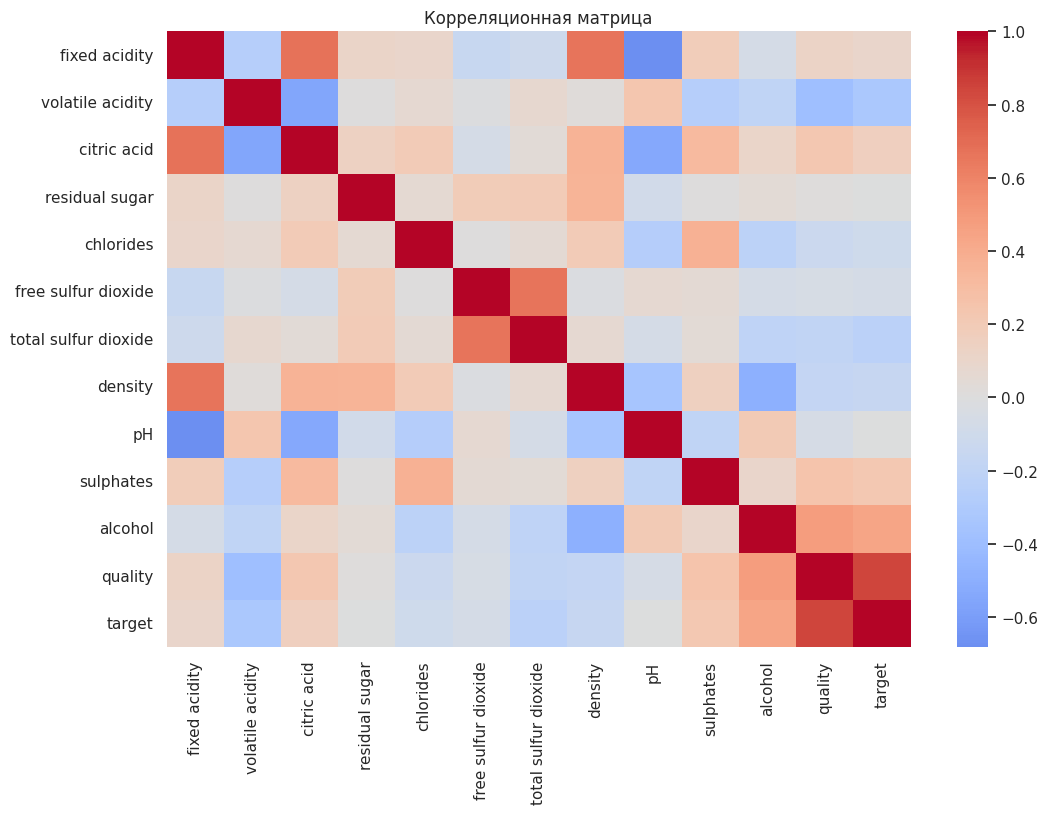

In [16]:

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Корреляционная матрица")
plt.show()


По матрице корреляций видно, что не все признаки независимы друг от друга.
Некоторые пары имеют более сильную связь, например free sulfur dioxide и total sulfur dioxide.
Также можно заметить, что alcohol положительно связан с quality, а volatile acidity — отрицательно.
Такой анализ помогает лучше понять данные и выделить признаки, которые могут сильнее влиять на качество вина.

In [48]:
df["target"] = (df["quality"] >= 6).astype(int)

In [49]:
print(df.columns.tolist())

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'target']


In [50]:
target_corr = (
    df.drop(columns=["quality"])
      .corr(numeric_only=True)["target"]
      .drop("target")
      .sort_values(ascending=False)
      .to_frame("correlation_with_target")
      .round(3)
)

print(target_corr.to_string())

                      correlation_with_target
alcohol                                 0.435
sulphates                               0.218
citric acid                             0.159
fixed acidity                           0.095
residual sugar                         -0.002
pH                                     -0.003
free sulfur dioxide                    -0.062
chlorides                              -0.109
density                                -0.159
total sulfur dioxide                   -0.232
volatile acidity                       -0.321


По корреляции с целевой переменной видно, что среди признаков наиболее сильную положительную связь имеют alcohol, sulphates и citric acid.
Это означает, что при увеличении этих показателей вероятность попадания вина в класс более высокого качества возрастает.
Наиболее выраженная отрицательная связь наблюдается у volatile acidity и total sulfur dioxide.
Следовательно, эти признаки можно считать наиболее информативными для дальнейшего построения модели.

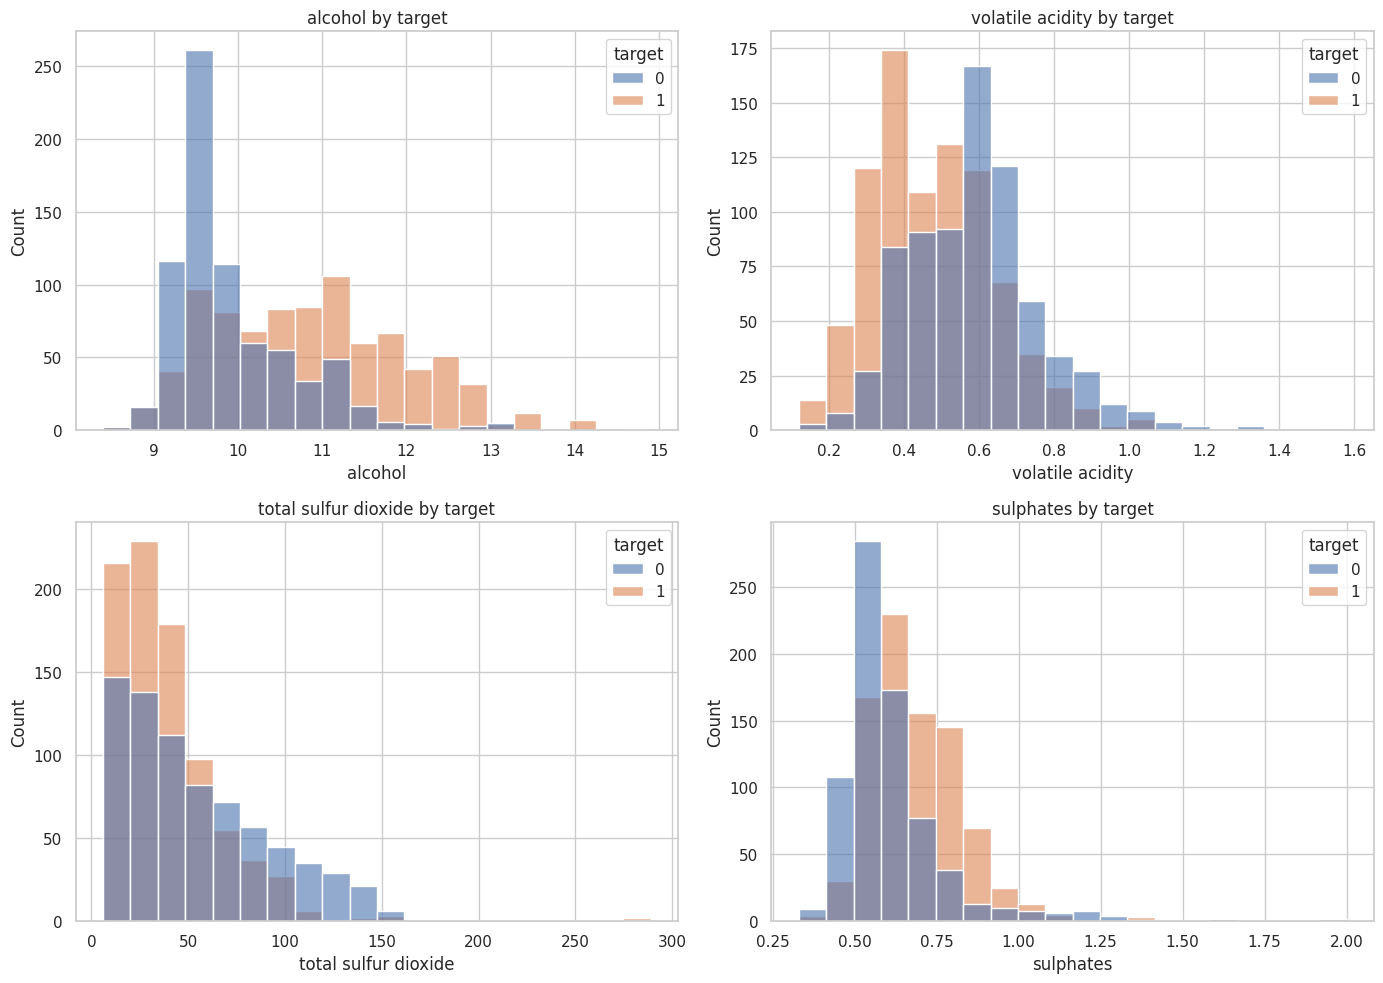

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = (
    df.drop(columns=["quality"])
      .corr(numeric_only=True)["target"]
      .drop("target")
      .abs()
      .sort_values(ascending=False)
      .head(4)
      .index
      .tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, top_features):
    sns.histplot(
        data=df,
        x=col,
        hue="target",
        bins=20,
        alpha=0.6,
        multiple="layer",
        ax=ax
    )
    ax.set_title(f"{col} by target")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

Были построены распределения самых информативных признаков по двум классам.
По графикам видно, что классы частично разделяются по этим признакам.
Например, у хороших вин обычно выше alcohol, а volatile acidity чаще ниже.
Значит, эти признаки можно считать важными для дальнейшего моделирования.


### Промежуточные выводы по EDA
После выполнения ячеек ниже здесь можно кратко записать наблюдения, например:

- есть/нет пропусков;
- есть/нет дубликатов;
- какие признаки сильнее всего связаны с качеством;
- есть ли перекос классов;
- какие признаки содержат заметные выбросы.


Сейчас подготовим данные:

In [20]:

X = df[features]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)


Размер обучающей выборки: (1279, 11)
Размер тестовой выборки: (320, 11)


In [21]:

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42
    )
}


Для задачи были выбраны три модели: логистическая регрессия, дерево решений и случайный лес.
Логистическая регрессия взята как базовая модель для сравнения.
Дерево решений и случайный лес позволяют учитывать более сложные зависимости в данных.
Для логистической регрессии дополнительно используется масштабирование признаков, так как это может улучшить качество модели.
Такое сравнение позволяет понять, какая из моделей лучше подходит для данного датасета

In [52]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }

    if y_proba is not None:
        row["roc_auc"] = roc_auc_score(y_test, y_proba)
    else:
        row["roc_auc"] = np.nan

    results.append(row)

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).round(3)
print(results_df.to_string(index=False))

              model  accuracy  precision  recall    f1  roc_auc
      Random Forest     0.778      0.805   0.772 0.788    0.875
Logistic Regression     0.741      0.768   0.737 0.752    0.824
      Decision Tree     0.731      0.754   0.737 0.746    0.783


После обучения моделей было проведено их сравнение по нескольким метрикам.
Лучше всего себя показал Random Forest, так как у него самые высокие значения основных метрик.
Logistic Regression тоже дала неплохой результат, но немного уступила.
Decision Tree показала худшее качество среди трёх моделей.
Поэтому в дальнейшем в качестве лучшей модели можно выбрать Random Forest.

In [23]:

best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print(f"Лучшая модель по F1-score: {best_model_name}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_best))


Лучшая модель по F1-score: Random Forest

Classification report:
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       149
           1       0.80      0.77      0.79       171

    accuracy                           0.78       320
   macro avg       0.78      0.78      0.78       320
weighted avg       0.78      0.78      0.78       320



После дополнительной проверки лучшей моделью остался Random Forest.
По classification report видно, что модель достаточно ровно работает на обоих классах и не имеет сильного перекоса в одну сторону.
Значения метрик находятся примерно на уровне 0.77–0.80, а общая точность составляет 0.78.
Это позволяет сделать вывод, что выбранная модель достаточно хорошо решает задачу классификации качества вина

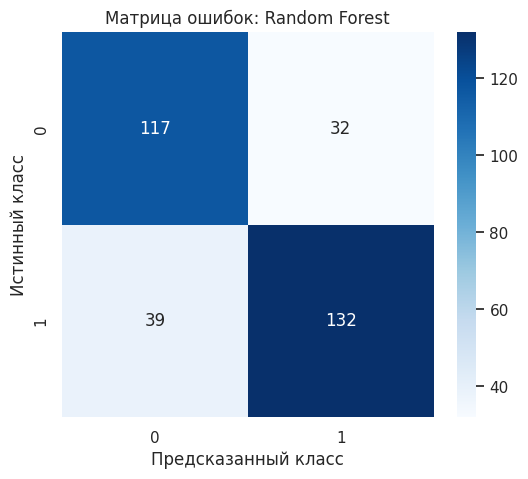

In [24]:

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Матрица ошибок: {best_model_name}")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()


По матрице ошибок видно, что модель чаще предсказывает классы правильно, чем ошибается.
Большая часть объектов обоих классов была распознана верно.
Ошибки есть в обе стороны, но их количество заметно меньше, чем число правильных предсказаний.
Это ещё раз подтверждает, что модель Random Forest достаточно хорошо подходит для решения данной задачи

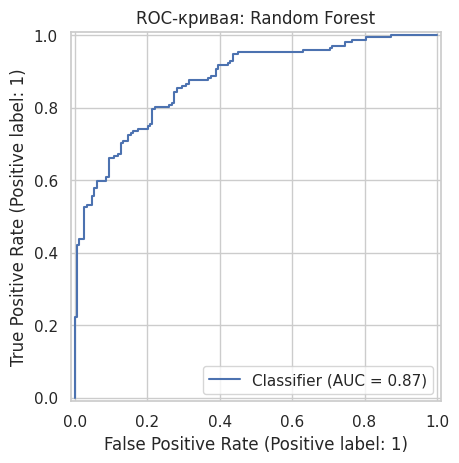

In [25]:

if hasattr(best_model, "predict_proba"):
    y_proba_best = best_model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba_best)
    plt.title(f"ROC-кривая: {best_model_name}")
    plt.show()
else:
    print("У данной модели нет predict_proba, ROC-кривая не строится.")


ROC-кривая показывает, насколько хорошо модель разделяет два класса.
На графике видно, что кривая проходит достаточно высоко, а значение AUC = 0.87, что считается хорошим результатом.
Это значит, что модель Random Forest хорошо отличает один класс от другого.
Следовательно, модель можно считать достаточно качественной для данной задачи

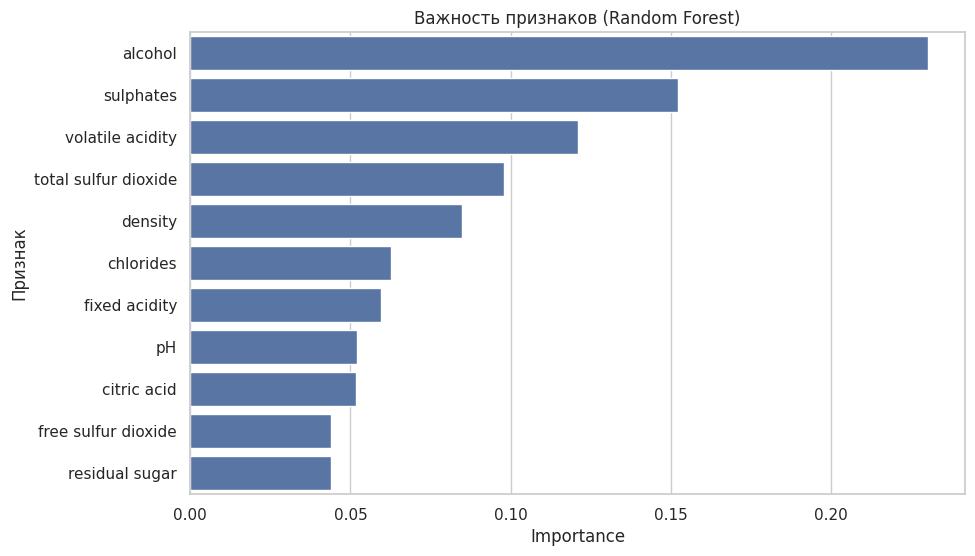

                      importance
alcohol                    0.230
sulphates                  0.152
volatile acidity           0.121
total sulfur dioxide       0.098
density                    0.085
chlorides                  0.063
fixed acidity              0.060
pH                         0.052
citric acid                0.052
free sulfur dioxide        0.044
residual sugar             0.044


In [56]:
if best_model_name == "Random Forest":
    importances = pd.Series(
        best_model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title("Важность признаков (Random Forest)")
    plt.xlabel("Importance")
    plt.ylabel("Признак")
    plt.show()

    print(importances.round(3).to_frame("importance").to_string())

elif best_model_name == "Logistic Regression":
    lr = best_model.named_steps["model"]
    coef = pd.Series(
        lr.coef_[0],
        index=X_train.columns
    ).sort_values(key=np.abs, ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=coef.values, y=coef.index)
    plt.title("Коэффициенты логистической регрессии")
    plt.xlabel("Coefficient")
    plt.ylabel("Признак")
    plt.show()

    print(coef.round(3).to_frame("coefficient").to_string())

else:
    print("Для выбранной модели можно интерпретировать дерево или дополнительно построить важности признаков.")

Для модели Random Forest была построена диаграмма важности признаков.
Она показывает, какие признаки сильнее всего влияют на предсказание качества вина.
По результатам видно, что наиболее значимыми являются alcohol, volatile acidity и sulphates.
Значит, именно эти признаки играют самую важную роль при классификации вин по качеству


## Итоговые выводы

После выполнения ноутбука здесь можно оставить итоговый текст, например:

1. В ходе EDA были изучены структура данных, распределения признаков, выбросы, корреляции и баланс классов.
2. Целевая переменная была сведена к бинарной классификации: хорошие вина (`quality >= 6`) и остальные.
3. Были обучены и сравнены модели:
   - Logistic Regression
   - Decision Tree
   - Random Forest
4. Для оценки использовались метрики:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
5. По итогам сравнения была выбрана лучшая модель, а также проанализированы наиболее значимые признаки.

> В этот раздел лучше вписать 4–6 конкретных предложений уже по своим результатам после запуска всех ячеек.



## Что можно улучшить в будущем
- Подобрать гиперпараметры моделей.
- Проверить другие алгоритмы классификации.
- Попробовать многоклассовую классификацию по исходному `quality`.
- Исследовать методы обработки выбросов.
